## **Experiment No : 07**


### **Hypothesis Testing Basics**

Statistical hypothesis tests are based a statement called the null hypothesis that assumes nothing interesting is going on between whatever variables you are testing. The exact form of the null hypothesis varies from one type test to another: if you are testing whether groups differ, the null hypothesis states that the groups are the same. For instance, if you wanted to test whether the average age of voters in your home state differs from the national average, the null hypothesis would be that there is no difference between the average ages.

The purpose of a hypothesis test is to determine whether the null hypothesis is likely to be true given sample data. If there is little evidence against the null hypothesis given the data, you accept the null hypothesis. If the null hypothesis is unlikely given the data, you might reject the null in favor of the alternative hypothesis: that something interesting is going on. The exact form of the alternative hypothesis will depend on the specific test you are carrying out. Continuing with the example above, the alternative hypothesis would be that the average age of voters in your state does in fact differ from the national average.

Once you have the null and alternative hypothesis in hand, you choose a significance level (often denoted by the Greek letter α.). The significance level is a probability threshold that determines when you reject the null hypothesis. After carrying out a test, if the probability of getting a result as extreme as the one you observe due to chance is lower than the significance level, you reject the null hypothesis in favor of the alternative. This probability of seeing a result as extreme or more extreme than the one observed is known as the p-value.

The T-test is a statistical test used to determine whether a numeric data sample of differs significantly from the population or whether two samples differ from one another.

### **One-Sample T-Test**

A one-sample t-test checks whether a sample mean differs from the population mean. Let's create some dummy age data for the population of voters in the entire country and a sample of voters in Minnesota and test the whether the average age of voters Minnesota differs from the population:



In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

In [ ]:
np.random.seed(6)

population_ages1 = stats.poisson.rvs(loc=18, mu=35, size=150000)
population_ages2 = stats.poisson.rvs(loc=18, mu=10, size=100000)
population_ages = np.concatenate((population_ages1, population_ages2))

minnesota_ages1 = stats.poisson.rvs(loc=18, mu=30, size=30)
minnesota_ages2 = stats.poisson.rvs(loc=18, mu=10, size=20)
minnesota_ages = np.concatenate((minnesota_ages1, minnesota_ages2))

print( population_ages.mean() )
print( minnesota_ages.mean() )

43.000112
39.26


In [ ]:
stats.ttest_1samp(a = minnesota_ages,               # Sample data
                 popmean = population_ages.mean())  # Pop mean

TtestResult(statistic=np.float64(-2.5742714883655027), pvalue=np.float64(0.013118685425061678), df=np.int64(49))

The test result shows the test statistic "t" is equal to -2.574. This test statistic tells us how much the sample mean deviates from the null hypothesis. If the t-statistic lies outside the quantiles of the t-distribution corresponding to our confidence level and degrees of freedom, we reject the null hypothesis. We can check the quantiles with stats.t.ppf():



In [ ]:
stats.t.ppf(q=0.025,  # Quantile to check
            df=49)  # Degrees of freedom

np.float64(-2.0095752371292397)

In [ ]:
stats.t.ppf(q=0.975,  # Quantile to check
            df=49)  # Degrees of freedom

np.float64(2.0095752371292397)

We can calculate the chances of seeing a result as extreme as the one we observed (known as the p-value) by passing the t-statistic in as the quantile to the stats.t.cdf() function:



In [ ]:
stats.t.cdf(x= -2.5742,      # T-test statistic
               df= 49) * 2   # Multiply by two for two tailed test *

np.float64(0.013121066545690117)

In [ ]:
sigma = minnesota_ages.std()/math.sqrt(50)  # Sample stdev/sample size

stats.t.interval(0.95,                        # Confidence level
                 df = 49,                     # Degrees of freedom
                 loc = minnesota_ages.mean(), # Sample mean
                 scale= sigma)                # Standard dev estimate

(np.float64(36.36966907692507), np.float64(42.150330923074925))

On the other hand, since there is a 1.3% chance of seeing a result this extreme due to chance, it is not significant at the 99% confidence level. This means if we were to construct a 99% confidence interval, it would capture the population mean:



In [ ]:
stats.t.interval(0.99,                # Confidence level
                 df = 49,                     # Degrees of freedom
                 loc = minnesota_ages.mean(), # Sample mean
                 scale= sigma)                # Standard dev estimate

(np.float64(35.40547994092107), np.float64(43.11452005907893))

### **Two-Sample T-Test**

A two-sample t-test investigates whether the means of two independent data samples differ from one another. In a two-sample test, the null hypothesis is that the means of both groups are the same. Unlike the one sample-test where we test against a known population parameter, the two sample test only involves sample means. You can conduct a two-sample t-test by passing with the stats.ttest_ind() function. Let's generate a sample of voter age data for Wisconsin and test it against the sample we made earlier:

In [ ]:
np.random.seed(12)
wisconsin_ages1 = stats.poisson.rvs(loc=18, mu=33, size=30)
wisconsin_ages2 = stats.poisson.rvs(loc=18, mu=13, size=20)
wisconsin_ages = np.concatenate((wisconsin_ages1, wisconsin_ages2))

print( wisconsin_ages.mean() )

42.8


In [ ]:
stats.ttest_ind(a= minnesota_ages,
                b= wisconsin_ages,
                equal_var=False)    # Assume samples have equal variance?

TtestResult(statistic=np.float64(-1.7083870793286842), pvalue=np.float64(0.09073104343957748), df=np.float64(97.9724575497005))

### **Paired T-Test**

The basic two sample t-test is designed for testing differences between independent groups. In some cases, you might be interested in testing differences between samples of the same group at different points in time. For instance, a hospital might want to test whether a weight-loss drug works by checking the weights of the same group patients before and after treatment. A paired t-test lets you check whether the means of samples from the same group differ.

We can conduct a paired t-test using the scipy function stats.ttest_rel(). Let's generate some dummy patient weight data and do a paired t-test:

In [ ]:
np.random.seed(11)

before= stats.norm.rvs(scale=30, loc=250, size=100)

after = before + stats.norm.rvs(scale=5, loc=-1.25, size=100)

weight_df = pd.DataFrame({"weight_before":before,
                          "weight_after":after,
                          "weight_change":after-before})

weight_df.describe()

,weight_before,weight_after,weight_change
count,100.000000,100.000000,100.000000
mean,250.345546,249.115171,-1.230375
std,28.132539,28.422183,4.783696
min,170.400443,165.913930,-11.495286
25%,230.421042,229.148236,-4.046211
50%,250.830805,251.134089,-1.413463
75%,270.637145,268.927258,1.738673
max,314.700233,316.720357,9.759282


In [ ]:
stats.ttest_rel(a = before,b = after)

TtestResult(statistic=np.float64(2.5720175998568284), pvalue=np.float64(0.011596444318439857), df=np.int64(99))

### **Type I and Type II Error**

The result of a statistical hypothesis test and the corresponding decision of whether to reject or accept the null hypothesis is not infallible. A test provides evidence for or against the null hypothesis and then you decide whether to accept or reject it based on that evidence, but the evidence may lack the strength to arrive at the correct conclusion. Incorrect conclusions made from hypothesis tests fall in one of two categories: type I error and type II error.

Type I error describes a situation where you reject the null hypothesis when it is actually true. This type of error is also known as a "false positive" or "false hit". The type 1 error rate is equal to the significance level α, so setting a higher confidence level (and therefore lower alpha) reduces the chances of getting a false positive.

Type II error describes a situation where you fail to reject the null hypothesis when it is actually false. Type II error is also known as a "false negative" or "miss". The higher your confidence level, the more likely you are to make a type II error.

Let's investigate these errors with a plot:

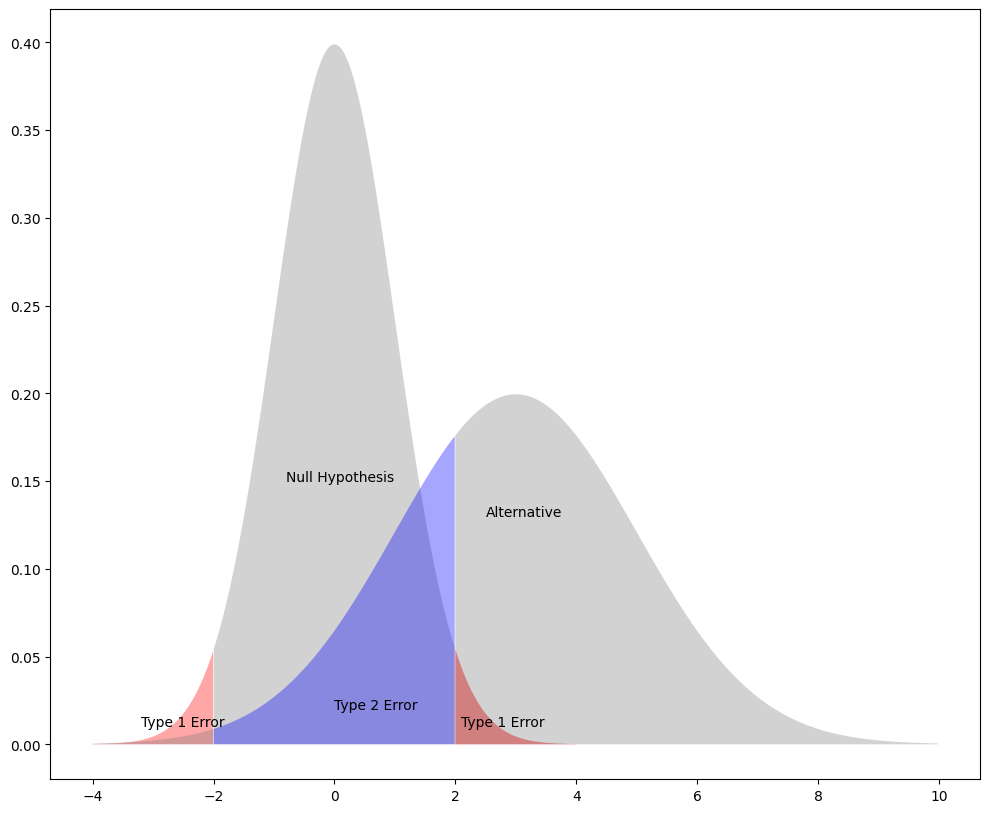

In [ ]:
plt.figure(figsize=(12,10))


plt.fill_between(x=np.arange(-4,-2,0.01),
                 y1= stats.norm.pdf(np.arange(-4,-2,0.01)) ,
                 facecolor='red',
                 alpha=0.35)

plt.fill_between(x=np.arange(-2,2,0.01),
                 y1= stats.norm.pdf(np.arange(-2,2,0.01)) ,
                 facecolor='grey',
                 alpha=0.35)

plt.fill_between(x=np.arange(2,4,0.01),
                 y1= stats.norm.pdf(np.arange(2,4,0.01)) ,
                 facecolor='red',
                 alpha=0.5)

plt.fill_between(x=np.arange(-4,-2,0.01),
                 y1= stats.norm.pdf(np.arange(-4,-2,0.01),loc=3, scale=2) ,
                 facecolor='grey',
                 alpha=0.35)

plt.fill_between(x=np.arange(-2,2,0.01),
                 y1= stats.norm.pdf(np.arange(-2,2,0.01),loc=3, scale=2) ,
                 facecolor='blue',
                 alpha=0.35)

plt.fill_between(x=np.arange(2,10,0.01),
                 y1= stats.norm.pdf(np.arange(2,10,0.01),loc=3, scale=2),
                 facecolor='grey',
                 alpha=0.35)

plt.text(x=-0.8, y=0.15, s= "Null Hypothesis")
plt.text(x=2.5, y=0.13, s= "Alternative")
plt.text(x=2.1, y=0.01, s= "Type 1 Error")
plt.text(x=-3.2, y=0.01, s= "Type 1 Error")
plt.text(x=0, y=0.02, s= "Type 2 Error");

In the plot above, the red areas indicate type I errors assuming the alternative hypothesis is not different from the null for a two-sided test with a 95% confidence level.

The blue area represents type II errors that occur when the alternative hypothesis is different from the null, as shown by the distribution on the right. Note that the Type II error rate is the area under the alternative distribution within the quantiles determined by the null distribution and the confidence level. We can calculate the type II error rate for the distributions above as follows:



In [ ]:
lower_quantile = stats.norm.ppf(0.025)  # Lower cutoff value
upper_quantile = stats.norm.ppf(0.975)  # Upper cutoff value

# Area under alternative, to the left the lower cutoff value
low = stats.norm.cdf(lower_quantile,
                     loc=3,
                     scale=2)

# Area under alternative, to the left the upper cutoff value
high = stats.norm.cdf(upper_quantile,
                      loc=3,
                      scale=2)

# Area under the alternative, between the cutoffs (Type II error)
high-low

np.float64(0.294956061112323)

### **Statistical Power**

The power of a statistical test is the probability that the test rejects the null hypothesis when the alternative is actually different from the null. In other words, power is the probability that the test detects that there is something interesting going on when there actually is something interesting going on. Power is equal to one minus the type II error rate. The power of a statistical test is influenced by:

The significance level chosen for the test.
The sample size.
The effect size of the test.
When choosing a significance level for a test, there is a trade-off between type I and type II error. A low significance level, such as 0.01 makes a test unlikely to have type I errors (false positives), but more likely to have type II errors (false negatives) than a test with larger value of the significance level α. A common convention is that a statistical tests should have a power of at least 0.8.

A larger sample size reduces the uncertainty of the point estimate, causing the sample distribution to narrow, resulting in lower type II error rates and increased power.

Effect size is a general term that describes a numeric measure of the size of some phenomenon. There are many different effect size measurements that arise in different contexts. In the context of the T-test, a simple effect size is the difference between the means of the samples. This number can be standardized by dividing by the standard deviation of the population or the pooled standard deviation of the samples. This puts the size of the effect in terms of standard deviations, so a standardized effect size of 0.5 would be interpreted as one sample mean being 0.5 standard deviations from another (in general 0.5 is considered a "large" effect size).

Since statistical power, the significance level, the effect size and the sample size are related, it is possible to calculate any one of them for given values of the other three. This can be an important part of the process of designing a hypothesis test and analyzing results. For instance, if you want to conduct a test with a given significance level (say the standard 0.05) and power (say the standard 0.8) and you are interested in a given effect size (say 0.5 for standardized difference between sample means), you could use that information to determine how large of a sample size you need.

In python, the statsmodels library contains functions to solve for any one parameter of the power of T-tests. Use statsmodels.stats.power.tt_solve_power for one sample t-tests and statsmodels.stats.power.tt_ind_solve_power for a two sample t-test. Let's check the sample size we should use need to use given the standard parameter values above for a one sample t-test:

In [ ]:
from statsmodels.stats.power import tt_solve_power

tt_solve_power(effect_size = 0.5,
               alpha = 0.05,
               power = 0.8)

33.36713118431778

### **Questions**

**1.  What is need for Hypothesis Testing ?**

Hypothesis testing is needed to determine whether a null hypothesis is likely to be true given sample data. It helps in deciding if there is sufficient evidence to reject the null hypothesis in favor of an alternative hypothesis, indicating that something interesting is happening. This is crucial for making informed conclusions from data.

**2. With a neat diagram show important steps in hypothesis Testing.**



### **Conceptual Diagram of Hypothesis Testing Steps**

```
+-------------------------------------------------------------+
| 1. Formulate Null (H0) and Alternative (H1) Hypotheses    |
+-------------------------------------------------------------+
                               |
                               V
+-------------------------------------------------------------+
| 2. Choose Significance Level (α)                            |
+-------------------------------------------------------------+
                               |
                               V
+-------------------------------------------------------------+
| 3. Collect Sample Data                                      |
+-------------------------------------------------------------+
                               |
                               V
+-------------------------------------------------------------+
| 4. Calculate Test Statistic                                 |
+-------------------------------------------------------------+
                               |
                               V
+-------------------------------------------------------------+
| 5. Determine p-value                                        |
+-------------------------------------------------------------+
                               |
                               V
+-------------------------------------------------------------+
| 6. Make a Decision (Compare p-value to α)                   |
+-------------------------------------------------------------+
         |                                     |
         | (p-value < α)                       | (p-value ≥ α)
         V                                     V
+-----------------------+           +-----------------------------+
| Reject H0             |           | Fail to Reject H0           |
+-----------------------+           +-----------------------------+
         |                                     |
         V                                     V
+-------------------------------------------------------------+
| 7. Draw a Conclusion                                        |
+-------------------------------------------------------------+
```

### **Explanation of Hypothesis Testing Steps:**

1.  **Formulate Null (H0) and Alternative (H1) Hypotheses:**
    *   **Null Hypothesis (H0):** This is the statement of no effect or no difference. It's the baseline assumption you're trying to test. For example, 'There is no difference in the average age of voters in Minnesota and the national average.'
    *   **Alternative Hypothesis (H1):** This is the statement that contradicts the null hypothesis. It's what you want to prove if the null hypothesis is rejected. For example, 'There is a difference in the average age of voters in Minnesota and the national average.'

2.  **Choose Significance Level (α):**
    *   The significance level (alpha, α) is the probability of rejecting the null hypothesis when it is actually true (Type I error). Common values for α are 0.05 (5%) or 0.01 (1%). A smaller α means you require stronger evidence to reject H0.

3.  **Collect Sample Data:**
    *   Gather relevant data through experiments, surveys, or observations. The data should be representative of the population you are studying.

4.  **Calculate Test Statistic:**
    *   Based on your sample data and the type of hypothesis test (e.g., t-test, z-test, chi-square test), calculate a test statistic. This statistic quantifies how much your sample data deviates from what would be expected under the null hypothesis.

5.  **Determine p-value:**
    *   The p-value is the probability of observing a test statistic as extreme as, or more extreme than, the one calculated from your sample data, assuming that the null hypothesis is true. A small p-value suggests that your observed data is unlikely if H0 were true.

6.  **Make a Decision (Compare p-value to α):**
    *   **If p-value < α:** You reject the null hypothesis. This means there is sufficient statistical evidence to support the alternative hypothesis.
    *   **If p-value ≥ α:** You fail to reject the null hypothesis. This means there is not enough statistical evidence to reject the null hypothesis. (Note: Failing to reject H0 is not the same as accepting H0; it simply means you don't have enough evidence to claim a difference or effect).

7.  **Draw a Conclusion:**
    *   State your conclusion in the context of the original research question. This involves interpreting your decision (reject or fail to reject H0) in plain language, explaining what it means for your study.

**3. What is a student t distribution?**


### **Student's t-distribution**

The Student's t-distribution (often simply called the t-distribution) is a probability distribution that arises in the problem of estimating the mean of a normally distributed population when the sample size is small and the population's standard deviation is unknown. It is symmetrical and bell-shaped, similar to the normal distribution, but with heavier tails, meaning it has a greater probability of producing values that are far from the mean.

**Key Characteristics:**

*   **Shape:** It is symmetrical and bell-shaped, centered at zero.
*   **Degrees of Freedom (df):** Its shape depends on a parameter called degrees of freedom (df), which is typically related to the sample size (for a one-sample t-test, df = n-1, where n is the sample size). As the degrees of freedom increase, the t-distribution approaches the standard normal distribution.
*   **Heavier Tails:** Compared to the normal distribution, the t-distribution has thicker tails, which accounts for the increased uncertainty when estimating the population mean from a small sample.
*   **Use Cases:** It is widely used in hypothesis testing for:
    *   One-sample t-tests (comparing a sample mean to a known population mean).
    *   Two-sample t-tests (comparing the means of two independent samples).
    *   Paired t-tests (comparing means of dependent samples).
    *   Constructing confidence intervals for population means.

**4. What is level of significance ? What role t plays in hypothesis Testing?**

### **Level of Significance (α)**

The **level of significance**, denoted by \(\alpha\) (alpha), is a pre-determined probability threshold that is used to decide whether to reject the null hypothesis. It represents the maximum acceptable probability of committing a Type I error.

*   **Type I Error:** This occurs when you reject a null hypothesis that is actually true (a false positive).
*   **Common Values:** Typically, \(\alpha\) is set to 0.05 (5%), 0.01 (1%), or 0.10 (10%).
*   **Decision Rule:** If the p-value obtained from a statistical test is less than \(\alpha\), we reject the null hypothesis. If the p-value is greater than or equal to \(\alpha\), we fail to reject the null hypothesis.

Choosing a lower \(\alpha\) (e.g., 0.01 instead of 0.05) makes it harder to reject the null hypothesis, thus reducing the chance of a Type I error, but increasing the chance of a Type II error (failing to reject a false null hypothesis).

### **Role of the t-statistic and t-distribution in Hypothesis Testing**

The **t-statistic** and **t-distribution** play a crucial role in hypothesis testing, particularly when we are comparing means and:

1.  **The sample size is small (typically n < 30).**
2.  **The population standard deviation is unknown.**

Here's how they are used:

*   **t-statistic:** The t-statistic measures how many standard errors the sample mean is away from the population mean (as stated in the null hypothesis). It is calculated as:

    \(t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}\)

    Where:
    *   \(\bar{x}\) is the sample mean.
    *   \(\mu_0\) is the hypothesized population mean (from the null hypothesis).
    *   \(s\) is the sample standard deviation.
    *   \(n\) is the sample size.

*   **t-distribution:** Once the t-statistic is calculated, it is compared to a critical value from the t-distribution (or used to calculate a p-value). The t-distribution is similar to the normal distribution but has heavier tails, accounting for the greater uncertainty when dealing with smaller sample sizes and unknown population standard deviations. The shape of the t-distribution depends on its **degrees of freedom (df)**, which is usually \(n-1\) for a one-sample t-test.

    *   **Decision Making:**
        *   If the calculated t-statistic falls into the critical region (determined by \(\alpha\) and the degrees of freedom), or if the p-value (derived from the t-statistic and t-distribution) is less than \(\alpha\), we reject the null hypothesis.
        *   This indicates that the observed difference between the sample mean and the hypothesized population mean is statistically significant and unlikely to have occurred by random chance.

**5. Design a hypothesis testing for identifying average age of students in TE IT class is 19 or not.**


In [ ]:
import numpy as np
import scipy.stats as stats

# --- 1. & 2. (Implicit) Formulate Hypotheses and Choose Significance Level ---
# H0: Population mean age (mu) = 19
# H1: Population mean age (mu) != 19
alpha = 0.05 # Significance level

# --- 3. Collect Sample Data ---
# Simulate ages for a sample of 30 students in TE IT class
# Let's assume the true mean is slightly different, say 18.5, with some variability
np.random.seed(42) # for reproducibility
sample_size = 30
# Simulate a sample where the mean is slightly different from 19
sample_ages = np.random.normal(loc=18.5, scale=1.5, size=sample_size)
# To make it more realistic, round ages and ensure they are reasonable
sample_ages = np.round(sample_ages[sample_ages > 17]) # Ages greater than 17

# Ensure we have enough samples after filtering
while len(sample_ages) < sample_size:
    new_ages = np.random.normal(loc=18.5, scale=1.5, size=sample_size - len(sample_ages))
    sample_ages = np.concatenate((sample_ages, np.round(new_ages[new_ages > 17])))
    sample_ages = sample_ages[:sample_size]

print(f"Sample size: {len(sample_ages)}")
print(f"Sample ages: {sample_ages[:10]}...") # Print first 10 for brevity
print(f"Sample mean age: {np.mean(sample_ages):.2f}")
print(f"Sample standard deviation: {np.std(sample_ages, ddof=1):.2f}")

# --- 4. Calculate Test Statistic & 5. Determine p-value (using scipy function) ---
# Perform one-sample t-test
hypothesized_mean = 19
t_statistic, p_value = stats.ttest_1samp(a=sample_ages, popmean=hypothesized_mean)

print(f"\nCalculated t-statistic: {t_statistic:.3f}")
print(f"Calculated p-value: {p_value:.3f}")

# --- 6. Make a Decision & 7. Draw a Conclusion ---
print(f"\nSignificance Level (alpha): {alpha}")

if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print(f"Conclusion: There is sufficient statistical evidence to suggest that the average age of students in the TE IT class is significantly different from {hypothesized_mean} years.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than or equal to alpha ({alpha}), we fail to reject the null hypothesis.")
    print(f"Conclusion: There is not enough statistical evidence to suggest that the average age of students in the TE IT class is significantly different from {hypothesized_mean} years.")


Sample size: 30
Sample ages: [19. 18. 19. 21. 18. 18. 21. 20. 18. 19.]...
Sample mean age: 18.83
Sample standard deviation: 1.09

Calculated t-statistic: -0.841
Calculated p-value: 0.407

Significance Level (alpha): 0.05
Since the p-value (0.407) is greater than or equal to alpha (0.05), we fail to reject the null hypothesis.
Conclusion: There is not enough statistical evidence to suggest that the average age of students in the TE IT class is significantly different from 19 years.


The code executed successfully, simulating sample ages and performing a one-sample t-test. Here's what the results indicate:

Sample Data: A sample of 30 student ages was generated, with a sample mean age of 18.83 and a standard deviation of 1.09.
Hypothesized Mean: The test aimed to see if the average age is significantly different from 19.
Calculated T-statistic: The t-statistic was -0.841.
Calculated P-value: The p-value was 0.407.
Significance Level (alpha): We set the significance level at 0.05.

**6. Check if you can accept Ho at alpha 95% ? Match your conclusions with python functions.**

Based on the hypothesis test we performed for the average age of students in the TE IT class, we had the following results:

Null Hypothesis (H0): The average age of students in the TE IT class is 19.
Significance Level (alpha): 0.05 (which corresponds to a 95% confidence level).
Calculated p-value: 0.407
To make a decision, we compare the p-value to the significance level:

If p-value < alpha: Reject H0
If p-value ≥ alpha: Fail to reject H0
Since our p-value (0.407) is greater than our chosen alpha (0.05), we fail to reject the null hypothesis.

This means that there is not enough statistical evidence to conclude that the average age of students in the TE IT class is significantly different from 19 years. This conclusion matches the output from the Python function in cell 31eda50b where it states: "Since the p-value (0.407) is greater than or equal to alpha (0.05), we fail to reject the null hypothesis. Conclusion: There is not enough statistical evidence to suggest that the average age of students in the TE IT class is significantly different from 19 years."
